# Análisis Exploratorio de Datos (EDA) - Detección de Fraude Financiero

Este cuaderno contiene el análisis descriptivo del conjunto de datos de transacciones financieras para identificar patrones relacionados con el fraude.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga de Datos

In [2]:
data_path = '../data/financial_fraud_detection_dataset.csv'
df = pd.read_csv(data_path)

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (5000000, 18)


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


## 2. Información General y Limpieza

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64


## 3. Análisis de la Variable Objetivo (`is_fraud`)

Distribución de fraude:
is_fraud
False    96.40894
True      3.59106
Name: proportion, dtype: float64


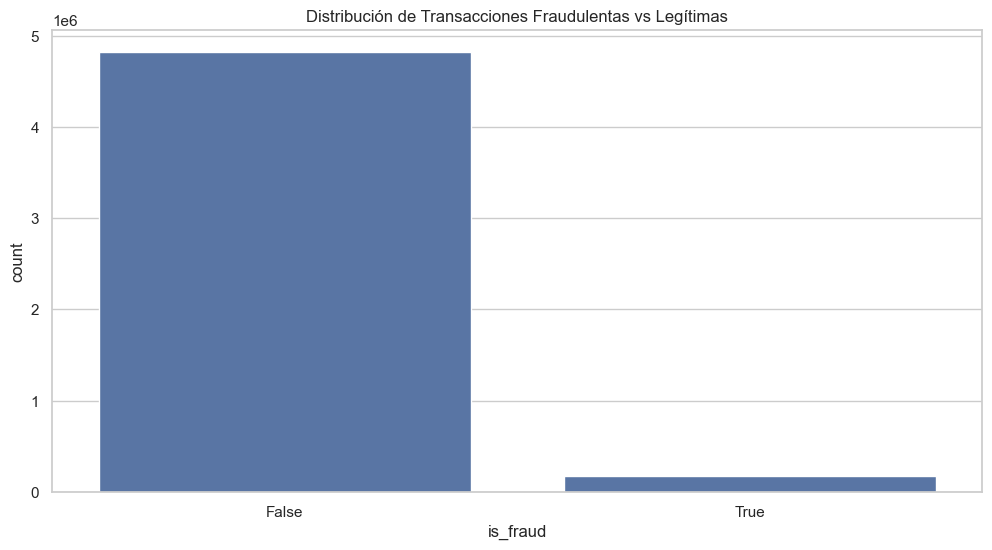

In [5]:
fraud_counts = df['is_fraud'].value_counts(normalize=True) * 100
print(f"Distribución de fraude:\n{fraud_counts}")

sns.countplot(x='is_fraud', data=df)
plt.title('Distribución de Transacciones Fraudulentas vs Legítimas')
plt.show()

## 4. Análisis de Variables Numéricas

In [6]:
numeric_cols = ['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score']
df[numeric_cols].describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01
std,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01
min,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01
50%,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01
75%,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01
max,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00


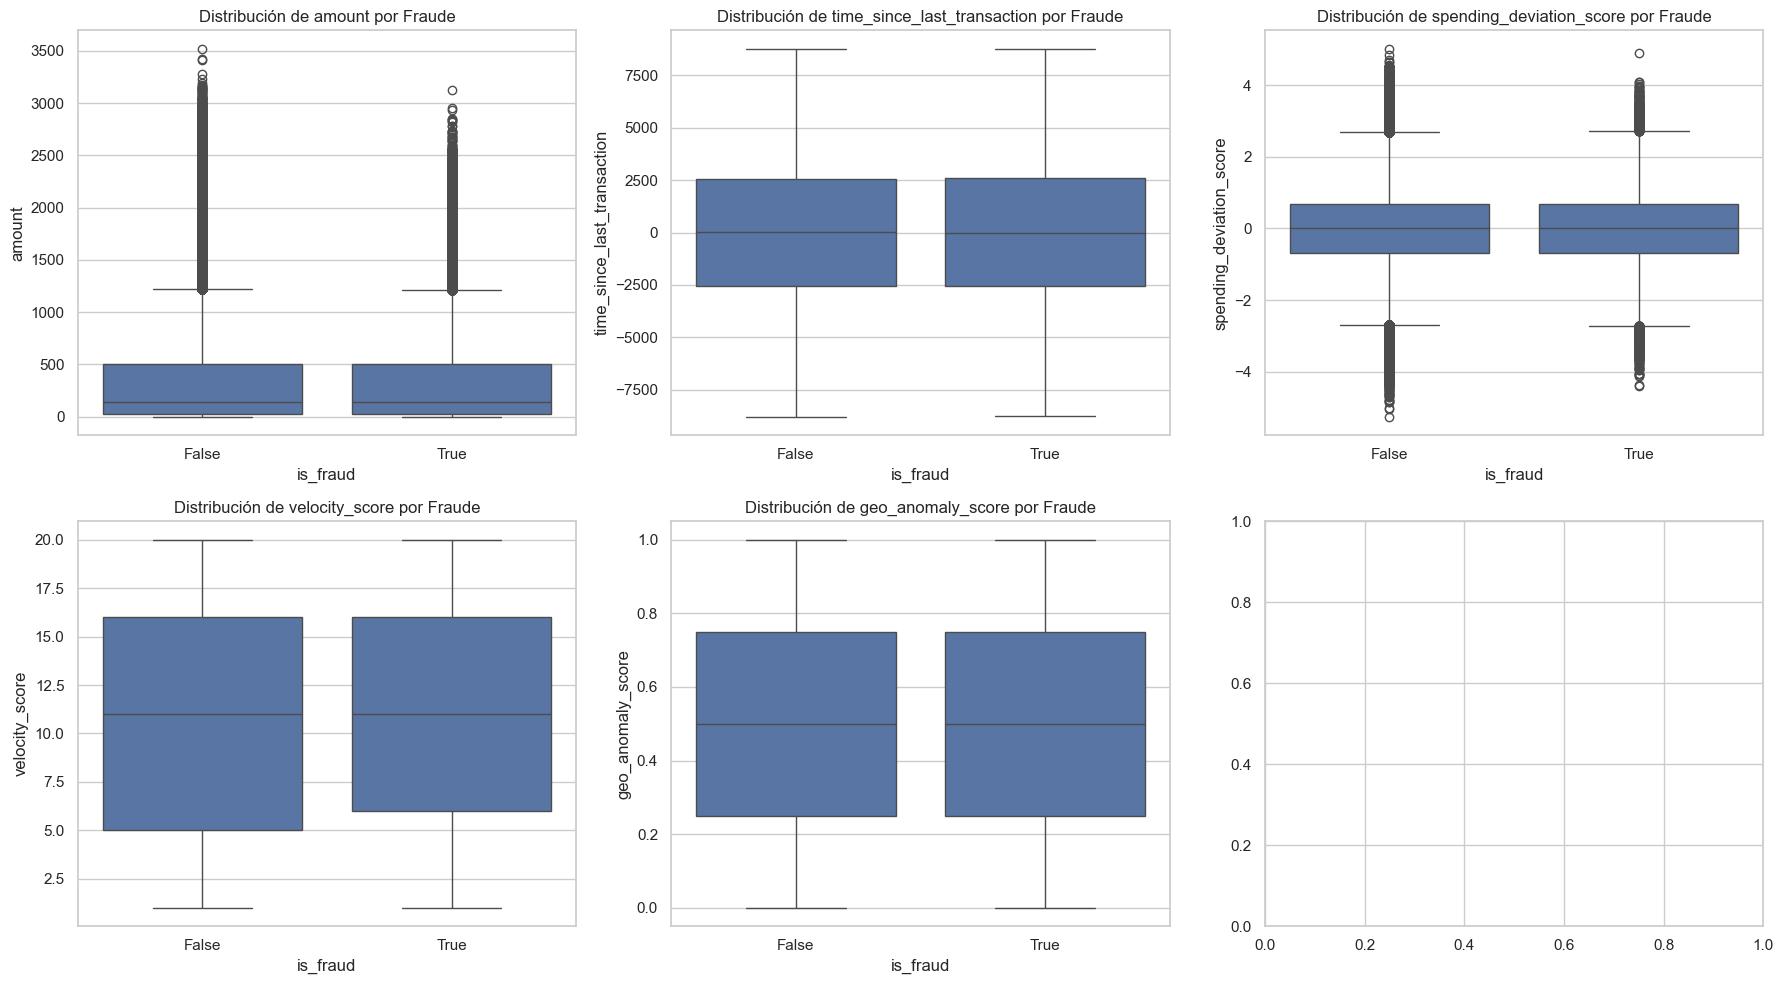

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='is_fraud', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribución de {col} por Fraude')

plt.tight_layout()
plt.show()

## 5. Análisis de Variables Categóricas

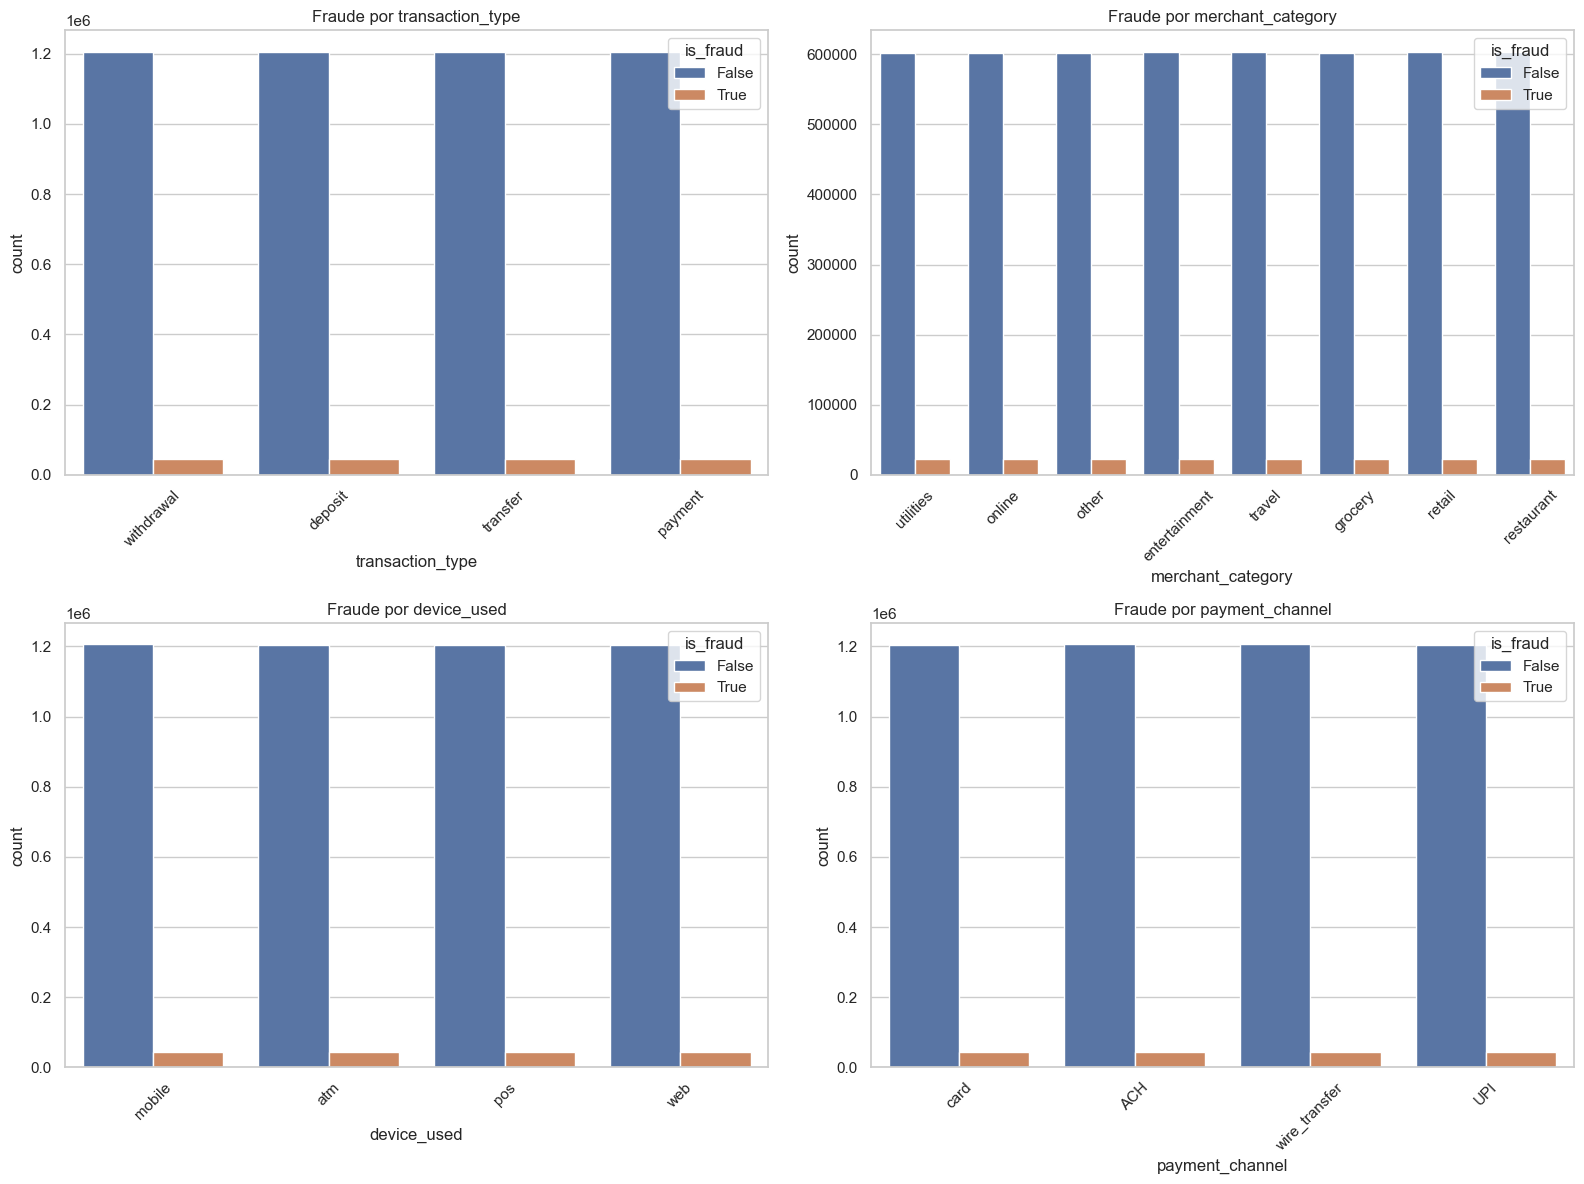

In [8]:
categorical_cols = ['transaction_type', 'merchant_category', 'device_used', 'payment_channel']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='is_fraud', data=df, ax=axes[i])
    axes[i].set_title(f'Fraude por {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Conclusiones Iniciales

- El dataset presenta un desequilibrio de clases (común en detección de fraude).
- Variables como `spending_deviation_score` y `velocity_score` parecen tener una relación clara con el fraude.
- Ciertos canales de pago o tipos de dispositivos podrían estar más asociados a actividades sospechosas.